TẢI DỮ LIỆU

In [1]:
import requests
import os
from pathlib import Path
import pandas as pd

# Tạo thư mục để lưu dữ liệu
data_dir = Path("vietnamese_students_feedback")
data_dir.mkdir(exist_ok=True)

# Google Drive file IDs (lấy từ script)
file_ids = {
    'train': {
        'sentences': '1nzak5OkrheRV1ltOGCXkT671bmjODLhP',
        'sentiments': '1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv',
        'topics': '14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C',
    },
    'validation': {
        'sentences': '1sMJSR3oRfPc3fe1gK-V3W5F24tov_517',
        'sentiments': '1GiY1AOp41dLXIIkgES4422AuDwmbUseL',
        'topics': '1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W',
    },
    'test': {
        'sentences': '1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n',
        'sentiments': '1vkQS5gI0is4ACU58-AbWusnemw7KZNfO',
        'topics': '1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB',
    },
}

def download_file_from_gdrive(file_id, destination):
    """Tải file từ Google Drive"""
    url = f"https://drive.google.com/uc?id={file_id}&export=download"
    
    session = requests.Session()
    response = session.get(url, stream=True)
    
    # Xử lý confirmation token nếu file lớn
    for key, value in response.cookies.items():
        if key.startswith('download_warning'):
            params = {'id': file_id, 'confirm': value, 'export': 'download'}
            response = session.get(url, params=params, stream=True)
            break
    
    # Lưu file
    with open(destination, 'wb') as f:
        for chunk in response.iter_content(32768):
            if chunk:
                f.write(chunk)
    
    print(f"✓ Đã tải: {destination}")

def load_split(split_name, file_ids_dict):
    """Tải và kết hợp dữ liệu cho một split"""
    split_dir = data_dir / split_name
    split_dir.mkdir(exist_ok=True)
    
    # Tải các file
    files = {}
    for file_type, file_id in file_ids_dict.items():
        filepath = split_dir / f"{file_type}.txt"
        if not filepath.exists():
            print(f"Đang tải {split_name}/{file_type}...")
            download_file_from_gdrive(file_id, filepath)
        files[file_type] = filepath
    
    # Đọc dữ liệu
    with open(files['sentences'], 'r', encoding='utf-8') as f:
        sentences = [line.strip() for line in f]
    
    with open(files['sentiments'], 'r', encoding='utf-8') as f:
        sentiments = [int(line.strip()) for line in f]
    
    with open(files['topics'], 'r', encoding='utf-8') as f:
        topics = [int(line.strip()) for line in f]
    
    # Tạo DataFrame
    df = pd.DataFrame({
        'sentence': sentences,
        'sentiment': sentiments,
        'topic': topics
    })
    
    # Thêm label names
    sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    topic_map = {0: 'lecturer', 1: 'training_program', 2: 'facility', 3: 'others'}
    
    df['sentiment_label'] = df['sentiment'].map(sentiment_map)
    df['topic_label'] = df['topic'].map(topic_map)
    
    return df

# Tải tất cả các splits
print("=" * 60)
print("Đang tải Vietnamese Students' Feedback Dataset...")
print("=" * 60)

dataset = {}
for split_name, ids in file_ids.items():
    print(f"\n[{split_name.upper()}]")
    dataset[split_name] = load_split(split_name, ids)
    print(f"Số mẫu: {len(dataset[split_name])}")

print("\n" + "=" * 60)
print("✓ Hoàn thành!")
print("=" * 60)

# Hiển thị thống kê
print("\n📊 THỐNG KÊ DATASET:")
for split_name, df in dataset.items():
    print(f"\n{split_name.upper()}:")
    print(f"  Tổng số mẫu: {len(df)}")
    print(f"  Sentiment distribution:")
    print(df['sentiment_label'].value_counts().to_string(header=False, index=True).replace('\n', '\n    '))
    print(f"  Topic distribution:")
    print(df['topic_label'].value_counts().to_string(header=False, index=True).replace('\n', '\n    '))

# Hiển thị ví dụ
print("\n" + "=" * 60)
print("📝 VÍ DỤ TỪ TRAIN SET:")
print("=" * 60)
for i in range(min(3, len(dataset['train']))):
    row = dataset['train'].iloc[i]
    print(f"\nMẫu {i+1}:")
    print(f"  Câu: {row['sentence']}")
    print(f"  Sentiment: {row['sentiment_label']}")
    print(f"  Topic: {row['topic_label']}")

# Lưu thành CSV (tùy chọn)
print("\n" + "=" * 60)
print("💾 Lưu dữ liệu thành CSV...")
for split_name, df in dataset.items():
    csv_path = data_dir / f"{split_name}.csv"
    df.to_csv(csv_path, index=False, encoding='utf-8')
    print(f"✓ Đã lưu: {csv_path}")

print("\n✅ Dataset đã sẵn sàng sử dụng!")
print(f"Truy cập: dataset['train'], dataset['validation'], dataset['test']")

Đang tải Vietnamese Students' Feedback Dataset...

[TRAIN]
Số mẫu: 11426

[VALIDATION]
Số mẫu: 1583

[TEST]
Số mẫu: 3166

✓ Hoàn thành!

📊 THỐNG KÊ DATASET:

TRAIN:
  Tổng số mẫu: 11426
  Sentiment distribution:
positive    5643
    negative    5325
    neutral      458
  Topic distribution:
lecturer            8166
    training_program    2201
    others               562
    facility             497

VALIDATION:
  Tổng số mẫu: 1583
  Sentiment distribution:
positive    805
    negative    705
    neutral      73
  Topic distribution:
lecturer            1151
    training_program     267
    others                95
    facility              70

TEST:
  Tổng số mẫu: 3166
  Sentiment distribution:
positive    1590
    negative    1409
    neutral      167
  Topic distribution:
lecturer            2290
    training_program     572
    others               159
    facility             145

📝 VÍ DỤ TỪ TRAIN SET:

Mẫu 1:
  Câu: slide giáo trình đầy đủ .
  Sentiment: positive
  Topic: train

In [2]:
# Truy cập dữ liệu
train_df = dataset['train']
val_df = dataset['validation']
test_df = dataset['test']

# Xem dữ liệu
print(train_df.head())
print(train_df.info())

# Lọc theo sentiment
positive_feedback = train_df[train_df['sentiment_label'] == 'positive']

# Lọc theo topic
lecturer_feedback = train_df[train_df['topic_label'] == 'lecturer']

                                            sentence  sentiment  topic  \
0                          slide giáo trình đầy đủ .          2      1   
1     nhiệt tình giảng dạy , gần gũi với sinh viên .          2      0   
2               đi học đầy đủ full điểm chuyên cần .          0      1   
3  chưa áp dụng công nghệ thông tin và các thiết ...          0      0   
4  thầy giảng bài hay , có nhiều bài tập ví dụ ng...          2      0   

  sentiment_label       topic_label  
0        positive  training_program  
1        positive          lecturer  
2        negative  training_program  
3        negative          lecturer  
4        positive          lecturer  
<class 'pandas.DataFrame'>
RangeIndex: 11426 entries, 0 to 11425
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   sentence         11426 non-null  str  
 1   sentiment        11426 non-null  int64
 2   topic            11426 non-null  int64
 3   senti

KHÁM PHÁ LÀM SẠCH DỮ LIỆU

📊 KHÁM PHÁ DỮ LIỆU (EDA)

1. TỔNG QUAN DỮ LIỆU

[TRAIN]
  Số mẫu: 11426
  Số cột: 5
  Kiểu dữ liệu:
sentence             str
    sentiment          int64
    topic              int64
    sentiment_label      str
    topic_label          str
  Missing values: 0
  Duplicates: 0

[VALIDATION]
  Số mẫu: 1583
  Số cột: 5
  Kiểu dữ liệu:
sentence             str
    sentiment          int64
    topic              int64
    sentiment_label      str
    topic_label          str
  Missing values: 0
  Duplicates: 0

[TEST]
  Số mẫu: 3166
  Số cột: 5
  Kiểu dữ liệu:
sentence             str
    sentiment          int64
    topic              int64
    sentiment_label      str
    topic_label          str
  Missing values: 0
  Duplicates: 0

2. PHÂN TÍCH CHIỀU DÀI CÂU

[TRAIN]
  Chiều dài ký tự:
    Min: 4
    Max: 660
    Mean: 59.08
    Median: 47.00
  Số từ:
    Min: 2
    Max: 159
    Mean: 14.31
    Median: 11.00

[VALIDATION]
  Chiều dài ký tự:
    Min: 4
    Max: 718
    Mean: 56.36
    Med

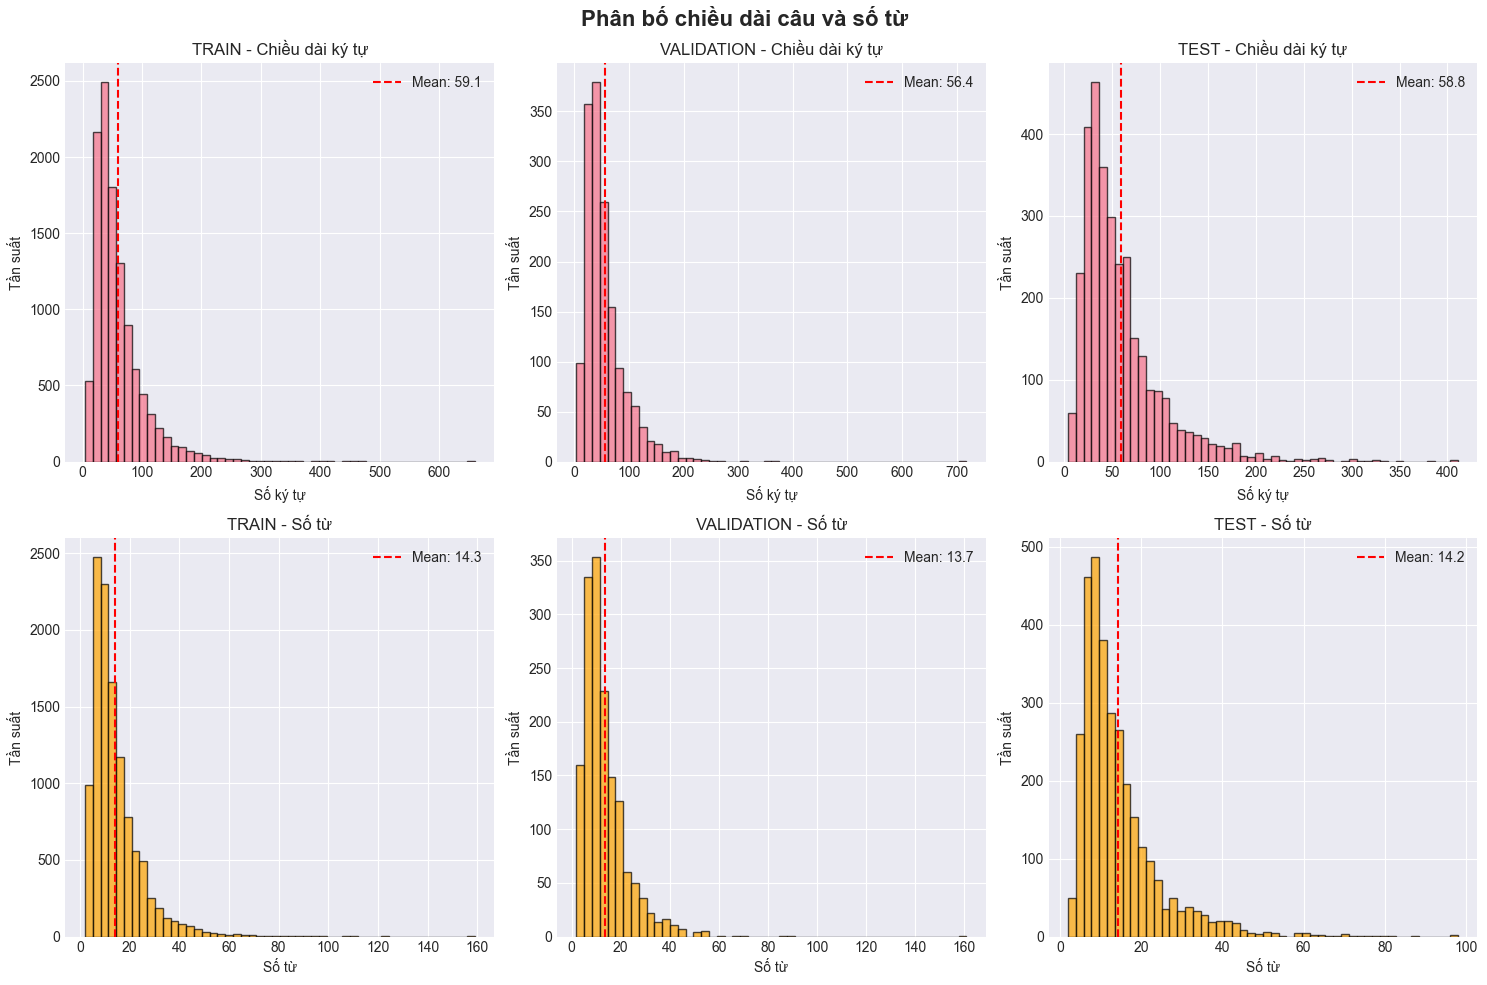


3. PHÂN BỐ NHÃN


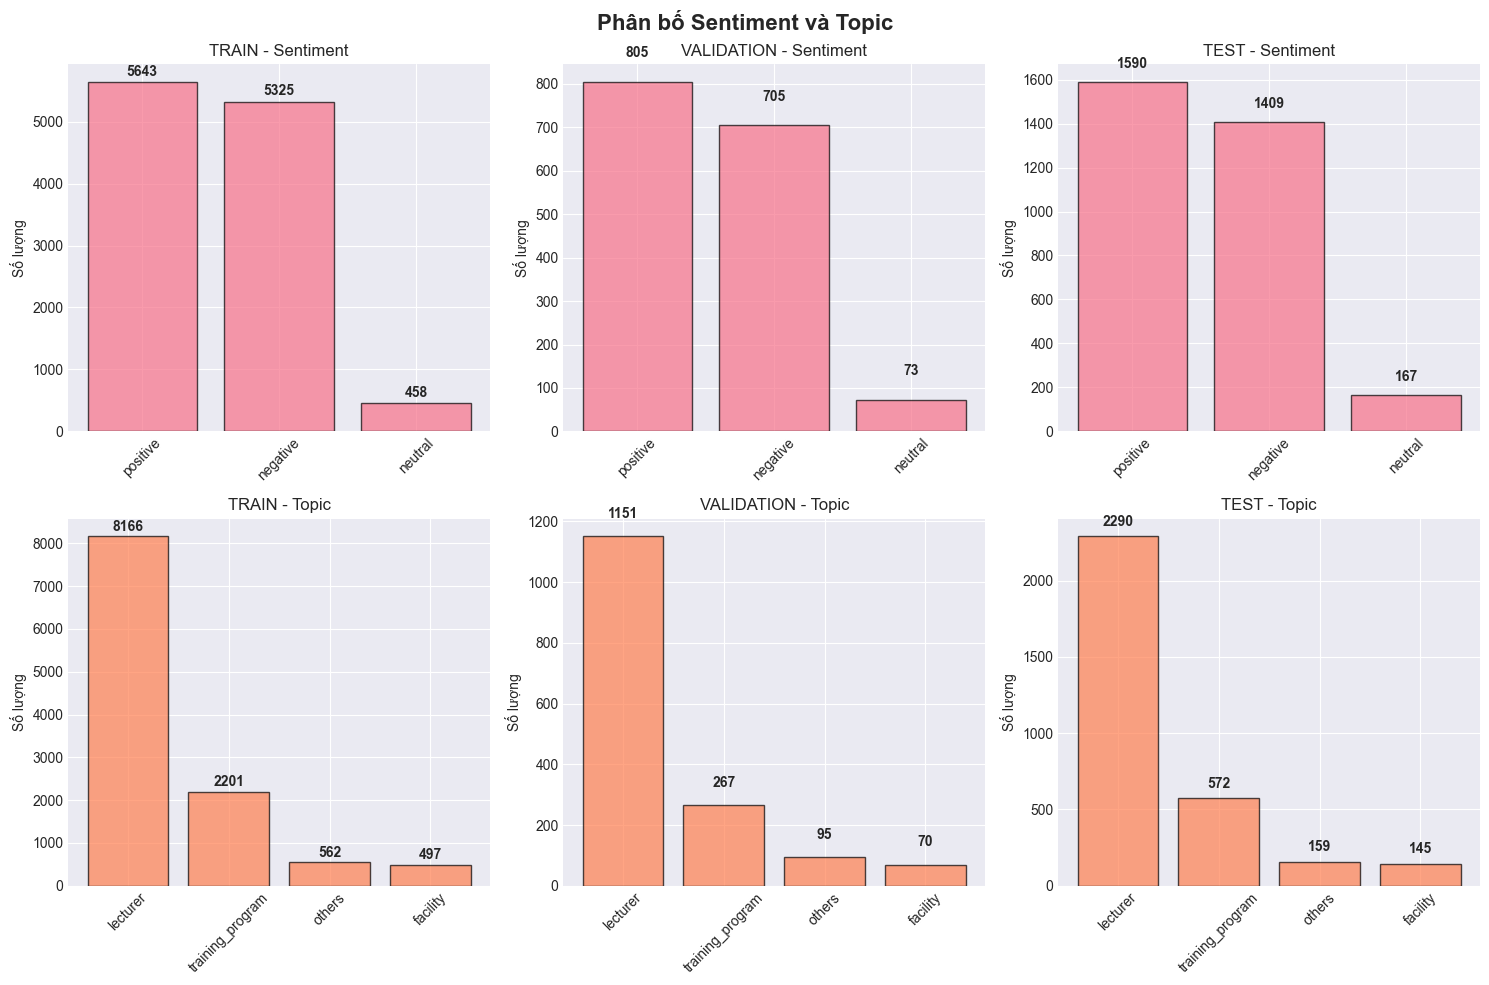


Phân bố phần trăm:

[TRAIN]
  Sentiment:
sentiment_label
    positive    49.39
    negative    46.60
    neutral      4.01
  Topic:
topic_label
    lecturer            71.47
    training_program    19.26
    others               4.92
    facility             4.35

[VALIDATION]
  Sentiment:
sentiment_label
    positive    50.85
    negative    44.54
    neutral      4.61
  Topic:
topic_label
    lecturer            72.71
    training_program    16.87
    others               6.00
    facility             4.42

[TEST]
  Sentiment:
sentiment_label
    positive    50.22
    negative    44.50
    neutral      5.27
  Topic:
topic_label
    lecturer            72.33
    training_program    18.07
    others               5.02
    facility             4.58

4. PHÁT HIỆN VẤN ĐỀ TRONG DỮ LIỆU

[TRAIN]
  ❌ Câu rỗng: 0
  ⚠️  Câu quá ngắn (< 10 ký tự): 64
     Ví dụ: ['dạy kỹ .', 'không !', 'hơi khó .']
  ⚠️  Câu quá dài (> 500 ký tự): 1
     Ví dụ: thầy cho nghỉ quá nhiểu mà không sắp xếp giáo viê

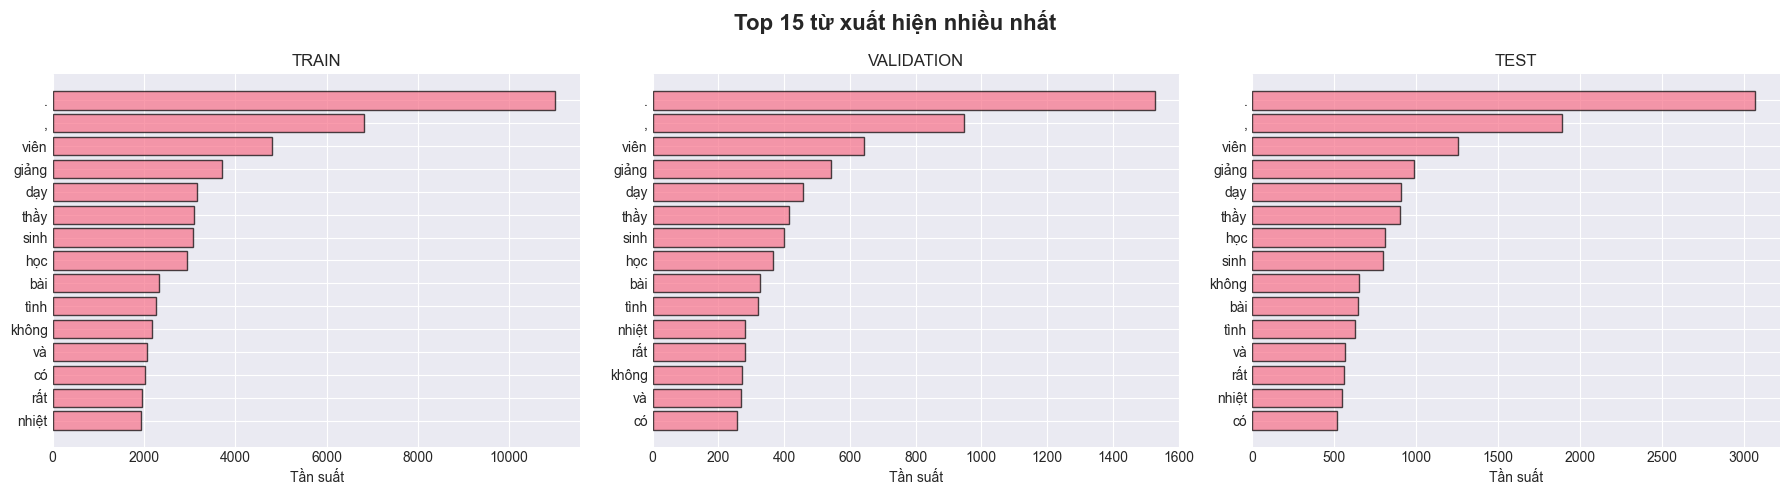


6. LÀM SẠCH DỮ LIỆU

[TRAIN]
  ✓ Loại bỏ câu rỗng: 0 câu
  ✓ Loại bỏ duplicates: 1 câu
  ✓ Loại bỏ câu quá ngắn (< 5 từ): 416 câu
  📊 Kết quả: 11426 → 11009 câu (giữ lại 96.35%)

[VALIDATION]
  ✓ Loại bỏ câu rỗng: 0 câu
  ✓ Loại bỏ duplicates: 0 câu
  ✓ Loại bỏ câu quá ngắn (< 5 từ): 76 câu
  📊 Kết quả: 1583 → 1507 câu (giữ lại 95.20%)

[TEST]
  ✓ Loại bỏ câu rỗng: 0 câu
  ✓ Loại bỏ duplicates: 0 câu
  ✓ Loại bỏ câu quá ngắn (< 5 từ): 146 câu
  📊 Kết quả: 3166 → 3020 câu (giữ lại 95.39%)

7. SO SÁNH TRƯỚC VÀ SAU KHI LÀM SẠCH


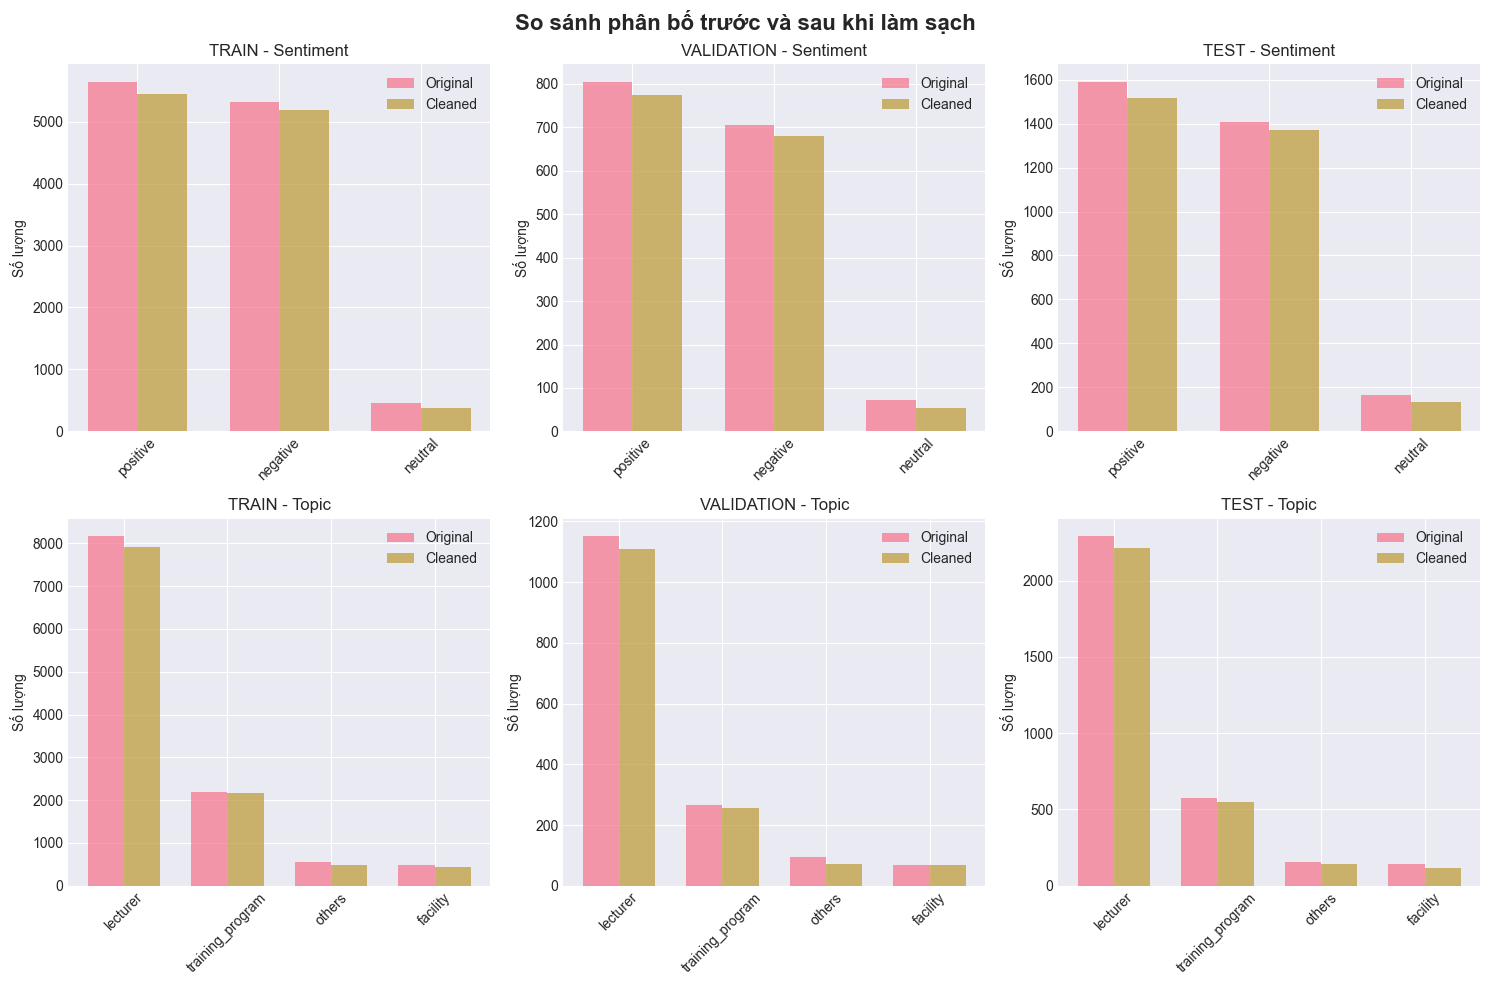


8. LƯU DỮ LIỆU ĐÃ LÀM SẠCH
✓ Đã lưu: vietnamese_students_feedback_clean\train_clean.csv
✓ Đã lưu: vietnamese_students_feedback_clean\validation_clean.csv
✓ Đã lưu: vietnamese_students_feedback_clean\test_clean.csv

✅ HOÀN THÀNH KHÁM PHÁ VÀ LÀM SẠCH DỮ LIỆU!

Dữ liệu đã làm sạch được lưu tại: vietnamese_students_feedback_clean/

Bạn có thể sử dụng:
  - dataset_clean['train']
  - dataset_clean['validation']
  - dataset_clean['test']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Đặt style cho plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Giả sử bạn đã có dataset từ bước trước
# train_df = dataset['train']
# val_df = dataset['validation']
# test_df = dataset['test']

print("=" * 80)
print("📊 KHÁM PHÁ DỮ LIỆU (EDA)")
print("=" * 80)

# ============================================================================
# 1. TỔNG QUAN DỮ LIỆU
# ============================================================================
print("\n" + "=" * 80)
print("1. TỔNG QUAN DỮ LIỆU")
print("=" * 80)

def basic_info(df, split_name):
    print(f"\n[{split_name}]")
    print(f"  Số mẫu: {len(df)}")
    print(f"  Số cột: {len(df.columns)}")
    print(f"  Kiểu dữ liệu:")
    print(df.dtypes.to_string().replace('\n', '\n    '))
    print(f"  Missing values: {df.isnull().sum().sum()}")
    print(f"  Duplicates: {df.duplicated().sum()}")

for split_name in ['train', 'validation', 'test']:
    basic_info(dataset[split_name], split_name.upper())

# ============================================================================
# 2. PHÂN TÍCH CHIỀU DÀI CÂU
# ============================================================================
print("\n" + "=" * 80)
print("2. PHÂN TÍCH CHIỀU DÀI CÂU")
print("=" * 80)

def analyze_length(df, split_name):
    df['sentence_length'] = df['sentence'].str.len()
    df['word_count'] = df['sentence'].str.split().str.len()
    
    print(f"\n[{split_name}]")
    print(f"  Chiều dài ký tự:")
    print(f"    Min: {df['sentence_length'].min()}")
    print(f"    Max: {df['sentence_length'].max()}")
    print(f"    Mean: {df['sentence_length'].mean():.2f}")
    print(f"    Median: {df['sentence_length'].median():.2f}")
    
    print(f"  Số từ:")
    print(f"    Min: {df['word_count'].min()}")
    print(f"    Max: {df['word_count'].max()}")
    print(f"    Mean: {df['word_count'].mean():.2f}")
    print(f"    Median: {df['word_count'].median():.2f}")
    
    return df

for split_name in ['train', 'validation', 'test']:
    dataset[split_name] = analyze_length(dataset[split_name], split_name.upper())

# Vẽ histogram
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Phân bố chiều dài câu và số từ', fontsize=16, fontweight='bold')

for idx, split_name in enumerate(['train', 'validation', 'test']):
    df = dataset[split_name]
    
    # Chiều dài ký tự
    axes[0, idx].hist(df['sentence_length'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{split_name.upper()} - Chiều dài ký tự')
    axes[0, idx].set_xlabel('Số ký tự')
    axes[0, idx].set_ylabel('Tần suất')
    axes[0, idx].axvline(df['sentence_length'].mean(), color='red', linestyle='--', 
                         label=f'Mean: {df["sentence_length"].mean():.1f}')
    axes[0, idx].legend()
    
    # Số từ
    axes[1, idx].hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1, idx].set_title(f'{split_name.upper()} - Số từ')
    axes[1, idx].set_xlabel('Số từ')
    axes[1, idx].set_ylabel('Tần suất')
    axes[1, idx].axvline(df['word_count'].mean(), color='red', linestyle='--',
                         label=f'Mean: {df["word_count"].mean():.1f}')
    axes[1, idx].legend()

plt.tight_layout()
plt.show()

# ============================================================================
# 3. PHÂN BỐ NHÃN
# ============================================================================
print("\n" + "=" * 80)
print("3. PHÂN BỐ NHÃN")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Phân bố Sentiment và Topic', fontsize=16, fontweight='bold')

for idx, split_name in enumerate(['train', 'validation', 'test']):
    df = dataset[split_name]
    
    # Sentiment
    sentiment_counts = df['sentiment_label'].value_counts()
    axes[0, idx].bar(sentiment_counts.index, sentiment_counts.values, edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{split_name.upper()} - Sentiment')
    axes[0, idx].set_ylabel('Số lượng')
    axes[0, idx].tick_params(axis='x', rotation=45)
    
    # Thêm giá trị lên các cột
    for i, v in enumerate(sentiment_counts.values):
        axes[0, idx].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')
    
    # Topic
    topic_counts = df['topic_label'].value_counts()
    axes[1, idx].bar(topic_counts.index, topic_counts.values, edgecolor='black', alpha=0.7, color='coral')
    axes[1, idx].set_title(f'{split_name.upper()} - Topic')
    axes[1, idx].set_ylabel('Số lượng')
    axes[1, idx].tick_params(axis='x', rotation=45)
    
    # Thêm giá trị lên các cột
    for i, v in enumerate(topic_counts.values):
        axes[1, idx].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# In ra phần trăm
print("\nPhân bố phần trăm:")
for split_name in ['train', 'validation', 'test']:
    df = dataset[split_name]
    print(f"\n[{split_name.upper()}]")
    print("  Sentiment:")
    print((df['sentiment_label'].value_counts(normalize=True) * 100).round(2).to_string().replace('\n', '\n    '))
    print("  Topic:")
    print((df['topic_label'].value_counts(normalize=True) * 100).round(2).to_string().replace('\n', '\n    '))

# ============================================================================
# 4. PHÁT HIỆN VÀ PHÂN TÍCH CÁC VẤN ĐỀ
# ============================================================================
print("\n" + "=" * 80)
print("4. PHÁT HIỆN VẤN ĐỀ TRONG DỮ LIỆU")
print("=" * 80)

def detect_issues(df, split_name):
    print(f"\n[{split_name}]")
    
    # Câu rỗng hoặc chỉ có khoảng trắng
    empty_sentences = df[df['sentence'].str.strip() == '']
    print(f"  ❌ Câu rỗng: {len(empty_sentences)}")
    
    # Câu quá ngắn (< 10 ký tự)
    too_short = df[df['sentence_length'] < 10]
    print(f"  ⚠️  Câu quá ngắn (< 10 ký tự): {len(too_short)}")
    if len(too_short) > 0:
        print(f"     Ví dụ: {too_short['sentence'].head(3).tolist()}")
    
    # Câu quá dài (> 500 ký tự) - có thể là outlier
    too_long = df[df['sentence_length'] > 500]
    print(f"  ⚠️  Câu quá dài (> 500 ký tự): {len(too_long)}")
    if len(too_long) > 0:
        print(f"     Ví dụ: {too_long['sentence'].head(1).tolist()[0][:100]}...")
    
    # Duplicates
    duplicates = df[df.duplicated(subset=['sentence'], keep=False)]
    print(f"  ❌ Câu trùng lặp: {len(duplicates)}")
    if len(duplicates) > 0:
        print(f"     Ví dụ: {duplicates['sentence'].head(2).tolist()}")
    
    # Ký tự đặc biệt hoặc số
    special_char_pattern = r'[^\w\s\u0080-\u024F\u1E00-\u1EFF]'
    has_special = df[df['sentence'].str.contains(special_char_pattern, regex=True, na=False)]
    print(f"  ℹ️  Câu có ký tự đặc biệt: {len(has_special)} ({len(has_special)/len(df)*100:.2f}%)")
    
    # Số
    has_numbers = df[df['sentence'].str.contains(r'\d', regex=True, na=False)]
    print(f"  ℹ️  Câu có số: {len(has_numbers)} ({len(has_numbers)/len(df)*100:.2f}%)")
    
    # Chữ HOA
    all_caps = df[df['sentence'].str.isupper()]
    print(f"  ℹ️  Câu toàn chữ HOA: {len(all_caps)}")
    
    return {
        'empty': empty_sentences,
        'too_short': too_short,
        'too_long': too_long,
        'duplicates': duplicates,
        'special_chars': has_special,
        'has_numbers': has_numbers,
        'all_caps': all_caps
    }

issues = {}
for split_name in ['train', 'validation', 'test']:
    issues[split_name] = detect_issues(dataset[split_name], split_name.upper())

# ============================================================================
# 5. TỪ VỰNG VÀ TỪ THƯỜNG XUẤT HIỆN
# ============================================================================
print("\n" + "=" * 80)
print("5. PHÂN TÍCH TỪ VỰNG")
print("=" * 80)

def analyze_vocabulary(df, split_name, top_n=20):
    print(f"\n[{split_name}]")
    
    # Tách từ
    all_words = ' '.join(df['sentence'].str.lower()).split()
    word_freq = Counter(all_words)
    
    print(f"  Tổng số từ: {len(all_words)}")
    print(f"  Từ vựng độc nhất: {len(word_freq)}")
    
    print(f"\n  Top {top_n} từ xuất hiện nhiều nhất:")
    for word, count in word_freq.most_common(top_n):
        print(f"    '{word}': {count}")
    
    return word_freq

vocab = {}
for split_name in ['train', 'validation', 'test']:
    vocab[split_name] = analyze_vocabulary(dataset[split_name], split_name.upper(), top_n=15)

# Vẽ top words
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Top 15 từ xuất hiện nhiều nhất', fontsize=16, fontweight='bold')

for idx, split_name in enumerate(['train', 'validation', 'test']):
    top_words = dict(vocab[split_name].most_common(15))
    axes[idx].barh(list(top_words.keys()), list(top_words.values()), edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{split_name.upper()}')
    axes[idx].set_xlabel('Tần suất')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

# ============================================================================
# 6. LÀM SẠCH DỮ LIỆU
# ============================================================================
print("\n" + "=" * 80)
print("6. LÀM SẠCH DỮ LIỆU")
print("=" * 80)

def clean_text(text):
    """Hàm làm sạch text"""
    if pd.isna(text):
        return ""
    
    # Loại bỏ khoảng trắng thừa
    text = ' '.join(text.split())
    
    # Loại bỏ khoảng trắng đầu cuối
    text = text.strip()
    
    # Có thể thêm các bước làm sạch khác tùy nhu cầu:
    # - Chuẩn hóa Unicode
    # - Loại bỏ emoji
    # - Xử lý dấu câu
    
    return text

def clean_dataset(df, split_name):
    print(f"\n[{split_name}]")
    df_clean = df.copy()
    original_size = len(df_clean)
    
    # Làm sạch text
    df_clean['sentence'] = df_clean['sentence'].apply(clean_text)
    
    # Loại bỏ câu rỗng
    df_clean = df_clean[df_clean['sentence'] != '']
    print(f"  ✓ Loại bỏ câu rỗng: {original_size - len(df_clean)} câu")
    
    # Loại bỏ duplicates (giữ lại bản đầu tiên)
    before_dedup = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['sentence'], keep='first')
    print(f"  ✓ Loại bỏ duplicates: {before_dedup - len(df_clean)} câu")
    
    # Tùy chọn: Loại bỏ câu quá ngắn (< 5 từ)
    before_short = len(df_clean)
    df_clean = df_clean[df_clean['word_count'] >= 5]
    print(f"  ✓ Loại bỏ câu quá ngắn (< 5 từ): {before_short - len(df_clean)} câu")
    
    # Reset index
    df_clean = df_clean.reset_index(drop=True)
    
    print(f"  📊 Kết quả: {original_size} → {len(df_clean)} câu (giữ lại {len(df_clean)/original_size*100:.2f}%)")
    
    return df_clean

dataset_clean = {}
for split_name in ['train', 'validation', 'test']:
    dataset_clean[split_name] = clean_dataset(dataset[split_name], split_name.upper())

# ============================================================================
# 7. SO SÁNH TRƯỚC VÀ SAU KHI LÀM SẠCH
# ============================================================================
print("\n" + "=" * 80)
print("7. SO SÁNH TRƯỚC VÀ SAU KHI LÀM SẠCH")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('So sánh phân bố trước và sau khi làm sạch', fontsize=16, fontweight='bold')

for idx, split_name in enumerate(['train', 'validation', 'test']):
    # Sentiment distribution
    original_sent = dataset[split_name]['sentiment_label'].value_counts()
    clean_sent = dataset_clean[split_name]['sentiment_label'].value_counts()
    
    x = np.arange(len(original_sent))
    width = 0.35
    
    axes[0, idx].bar(x - width/2, original_sent.values, width, label='Original', alpha=0.7)
    axes[0, idx].bar(x + width/2, clean_sent.values, width, label='Cleaned', alpha=0.7)
    axes[0, idx].set_title(f'{split_name.upper()} - Sentiment')
    axes[0, idx].set_xticks(x)
    axes[0, idx].set_xticklabels(original_sent.index, rotation=45)
    axes[0, idx].legend()
    axes[0, idx].set_ylabel('Số lượng')
    
    # Topic distribution
    original_topic = dataset[split_name]['topic_label'].value_counts()
    clean_topic = dataset_clean[split_name]['topic_label'].value_counts()
    
    x = np.arange(len(original_topic))
    
    axes[1, idx].bar(x - width/2, original_topic.values, width, label='Original', alpha=0.7)
    axes[1, idx].bar(x + width/2, clean_topic.values, width, label='Cleaned', alpha=0.7)
    axes[1, idx].set_title(f'{split_name.upper()} - Topic')
    axes[1, idx].set_xticks(x)
    axes[1, idx].set_xticklabels(original_topic.index, rotation=45)
    axes[1, idx].legend()
    axes[1, idx].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

# ============================================================================
# 8. LƯU DỮ LIỆU ĐÃ LÀM SẠCH
# ============================================================================
print("\n" + "=" * 80)
print("8. LƯU DỮ LIỆU ĐÃ LÀM SẠCH")
print("=" * 80)

from pathlib import Path
clean_dir = Path("vietnamese_students_feedback_clean")
clean_dir.mkdir(exist_ok=True)

for split_name, df in dataset_clean.items():
    csv_path = clean_dir / f"{split_name}_clean.csv"
    df.to_csv(csv_path, index=False, encoding='utf-8')
    print(f"✓ Đã lưu: {csv_path}")

print("\n" + "=" * 80)
print("✅ HOÀN THÀNH KHÁM PHÁ VÀ LÀM SẠCH DỮ LIỆU!")
print("=" * 80)
print(f"\nDữ liệu đã làm sạch được lưu tại: {clean_dir}/")
print("\nBạn có thể sử dụng:")
print("  - dataset_clean['train']")
print("  - dataset_clean['validation']")
print("  - dataset_clean['test']")

TIỀN XỬ LÝ DỮ LIỆU VÀ MÔ HÌNH

🚀 TIỀN XỬ LÝ VÀ XÂY DỰNG MÔ HÌNH

1. TIỀN XỬ LÝ TEXT NÂNG CAO
Đang tiền xử lý text...
  ✓ TRAIN: 11009 câu
  ✓ VALIDATION: 1507 câu
  ✓ TEST: 3020 câu

📝 Ví dụ tiền xử lý:

Mẫu 1:
  Original : slide giáo trình đầy đủ .
  Processed: slide giáo trình đầy đủ .

Mẫu 2:
  Original : nhiệt tình giảng dạy , gần gũi với sinh viên .
  Processed: nhiệt tình giảng dạy , gần gũi với sinh viên .

Mẫu 3:
  Original : đi học đầy đủ full điểm chuyên cần .
  Processed: đi học đầy đủ full điểm chuyên cần .

2. CHUẨN BỊ DỮ LIỆU CHO TRAINING

📊 Kích thước dữ liệu:
  Training: 12516 samples
  Test: 3020 samples

  Sentiment labels: [np.int64(0), np.int64(1), np.int64(2)]
  Topic labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

3. FEATURE EXTRACTION - TF-IDF

📈 Tạo TF-IDF features cho Sentiment...
  ✓ Sentiment features shape: (12516, 5000)
  ✓ Vocabulary size: 5000

📈 Tạo TF-IDF features cho Topic...
  ✓ Topic features shape: (12516, 5000)
  ✓ Vocabulary size: 5000

🔝 Top 20 features quan trọn

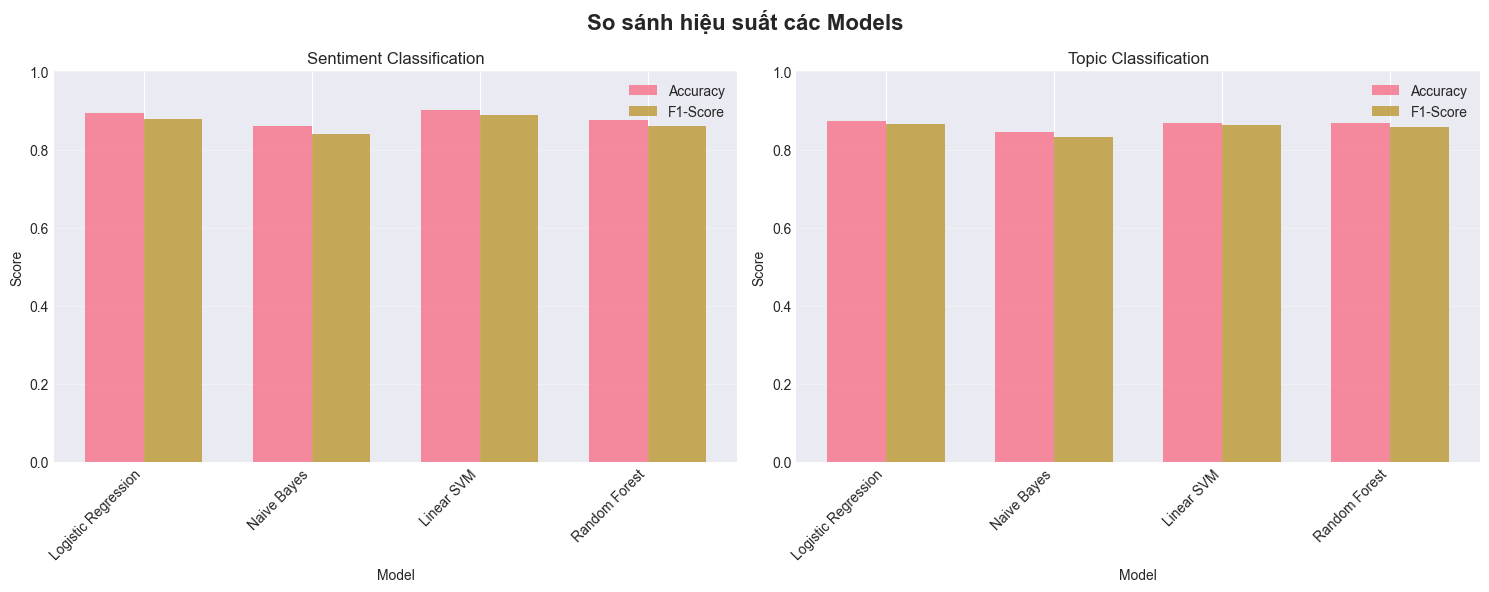


7. PHÂN TÍCH MÔ HÌNH TỐT NHẤT

🏆 Mô hình tốt nhất cho Sentiment: Linear SVM
🏆 Mô hình tốt nhất cho Topic: Logistic Regression

📋 Classification Report - Sentiment (Linear SVM):
              precision    recall  f1-score   support

    negative       0.88      0.95      0.92      1369
     neutral       0.68      0.14      0.23       135
    positive       0.92      0.92      0.92      1516

    accuracy                           0.90      3020
   macro avg       0.83      0.67      0.69      3020
weighted avg       0.89      0.90      0.89      3020


📋 Classification Report - Topic (Logistic Regression):
                  precision    recall  f1-score   support

        lecturer       0.91      0.95      0.93      2211
training_program       0.73      0.71      0.72       551
        facility       0.98      0.82      0.89       144
          others       0.64      0.18      0.29       114

        accuracy                           0.87      3020
       macro avg       0.81      0.

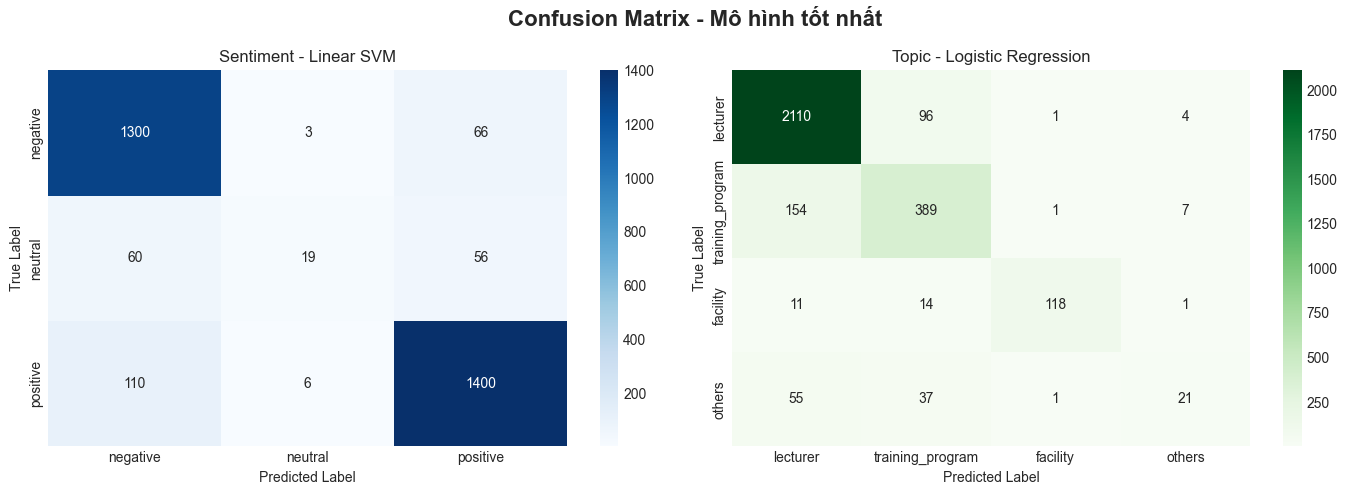


8. LƯU MÔ HÌNH VÀ VECTORIZERS
  ✓ Đã lưu sentiment model: Linear SVM
  ✓ Đã lưu topic model: Logistic Regression
  ✓ Đã lưu sentiment vectorizer
  ✓ Đã lưu topic vectorizer

9. DEMO DỰ ĐOÁN CHO INPUT MỚI

🎯 Demo dự đoán:

1. "Giảng viên dạy rất hay và dễ hiểu"
   → Sentiment: positive
   → Topic: lecturer (confidence: 99.64%)

2. "Cơ sở vật chất trường còn thiếu thốn"
   → Sentiment: negative
   → Topic: facility (confidence: 80.39%)

3. "Chương trình đào tạo cần cập nhật thêm"
   → Sentiment: negative
   → Topic: training_program (confidence: 94.33%)

✅ HOÀN THÀNH XÂY DỰNG MÔ HÌNH!

Mô hình đã được lưu tại: models/

Bạn có thể:
  1. Load model và dự đoán cho dữ liệu mới
  2. Fine-tune hyperparameters để cải thiện
  3. Thử nghiệm với Deep Learning models (LSTM, PhoBERT)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import re
import pickle
from pathlib import Path

# Giả sử bạn đã có dataset_clean từ bước trước
# train_df = dataset_clean['train']
# val_df = dataset_clean['validation']
# test_df = dataset_clean['test']

print("=" * 80)
print("🚀 TIỀN XỬ LÝ VÀ XÂY DỰNG MÔ HÌNH")
print("=" * 80)

# ============================================================================
# 1. TIỀN XỬ LÝ TEXT NÂNG CAO
# ============================================================================
print("\n" + "=" * 80)
print("1. TIỀN XỬ LÝ TEXT NÂNG CAO")
print("=" * 80)

def advanced_text_preprocessing(text):
    """
    Tiền xử lý text cho tiếng Việt
    """
    if pd.isna(text):
        return ""
    
    # Chuyển về lowercase
    text = text.lower()
    
    # Loại bỏ URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Loại bỏ email
    text = re.sub(r'\S+@\S+', '', text)
    
    # Loại bỏ số (tùy chọn - có thể giữ lại nếu số có ý nghĩa)
    # text = re.sub(r'\d+', '', text)
    
    # Loại bỏ ký tự đặc biệt nhưng giữ lại dấu câu cơ bản
    text = re.sub(r'[^\w\s\u0080-\u024F\u1E00-\u1EFF.,!?]', ' ', text)
    
    # Loại bỏ khoảng trắng thừa
    text = ' '.join(text.split())
    
    return text

print("Đang tiền xử lý text...")
for split_name in ['train', 'validation', 'test']:
    dataset_clean[split_name]['text_processed'] = dataset_clean[split_name]['sentence'].apply(advanced_text_preprocessing)
    print(f"  ✓ {split_name.upper()}: {len(dataset_clean[split_name])} câu")

# Hiển thị ví dụ
print("\n📝 Ví dụ tiền xử lý:")
for i in range(3):
    original = dataset_clean['train']['sentence'].iloc[i]
    processed = dataset_clean['train']['text_processed'].iloc[i]
    print(f"\nMẫu {i+1}:")
    print(f"  Original : {original}")
    print(f"  Processed: {processed}")

# ============================================================================
# 2. CHUẨN BỊ DỮ LIỆU CHO TRAINING
# ============================================================================
print("\n" + "=" * 80)
print("2. CHUẨN BỊ DỮ LIỆU CHO TRAINING")
print("=" * 80)

# Kết hợp train và validation để tăng dữ liệu training
train_full = pd.concat([dataset_clean['train'], dataset_clean['validation']], ignore_index=True)

# Chuẩn bị data cho sentiment classification
X_train_sent = train_full['text_processed']
y_train_sent = train_full['sentiment']
X_test_sent = dataset_clean['test']['text_processed']
y_test_sent = dataset_clean['test']['sentiment']

# Chuẩn bị data cho topic classification
X_train_topic = train_full['text_processed']
y_train_topic = train_full['topic']
X_test_topic = dataset_clean['test']['text_processed']
y_test_topic = dataset_clean['test']['topic']

print(f"\n📊 Kích thước dữ liệu:")
print(f"  Training: {len(X_train_sent)} samples")
print(f"  Test: {len(X_test_sent)} samples")
print(f"\n  Sentiment labels: {sorted(y_train_sent.unique())}")
print(f"  Topic labels: {sorted(y_train_topic.unique())}")

# ============================================================================
# 3. FEATURE EXTRACTION - TF-IDF
# ============================================================================
print("\n" + "=" * 80)
print("3. FEATURE EXTRACTION - TF-IDF")
print("=" * 80)

# TF-IDF Vectorizer cho Sentiment
print("\n📈 Tạo TF-IDF features cho Sentiment...")
tfidf_sent = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigram và bigram
    min_df=2,
    max_df=0.95
)

X_train_tfidf_sent = tfidf_sent.fit_transform(X_train_sent)
X_test_tfidf_sent = tfidf_sent.transform(X_test_sent)

print(f"  ✓ Sentiment features shape: {X_train_tfidf_sent.shape}")
print(f"  ✓ Vocabulary size: {len(tfidf_sent.vocabulary_)}")

# TF-IDF Vectorizer cho Topic
print("\n📈 Tạo TF-IDF features cho Topic...")
tfidf_topic = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf_topic = tfidf_topic.fit_transform(X_train_topic)
X_test_tfidf_topic = tfidf_topic.transform(X_test_topic)

print(f"  ✓ Topic features shape: {X_train_tfidf_topic.shape}")
print(f"  ✓ Vocabulary size: {len(tfidf_topic.vocabulary_)}")

# Top features
print("\n🔝 Top 20 features quan trọng nhất (TF-IDF):")
feature_names = tfidf_sent.get_feature_names_out()
tfidf_scores = np.asarray(X_train_tfidf_sent.mean(axis=0)).ravel()
top_indices = tfidf_scores.argsort()[-20:][::-1]
print("  " + ", ".join([f"'{feature_names[i]}'" for i in top_indices]))

# ============================================================================
# 4. XÂY DỰNG VÀ ĐÁNH GIÁ BASELINE MODELS
# ============================================================================
print("\n" + "=" * 80)
print("4. BASELINE MODELS - SENTIMENT CLASSIFICATION")
print("=" * 80)

# Định nghĩa các models
models_sent = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results_sent = {}

for model_name, model in models_sent.items():
    print(f"\n🔄 Training {model_name}...")
    
    # Train
    model.fit(X_train_tfidf_sent, y_train_sent)
    
    # Predict
    y_pred = model.predict(X_test_tfidf_sent)
    
    # Metrics
    acc = accuracy_score(y_test_sent, y_pred)
    f1 = f1_score(y_test_sent, y_pred, average='weighted')
    
    results_sent[model_name] = {
        'model': model,
        'accuracy': acc,
        'f1_score': f1,
        'predictions': y_pred
    }
    
    print(f"  ✓ Accuracy: {acc:.4f}")
    print(f"  ✓ F1-Score (weighted): {f1:.4f}")

# ============================================================================
# 5. BASELINE MODELS - TOPIC CLASSIFICATION
# ============================================================================
print("\n" + "=" * 80)
print("5. BASELINE MODELS - TOPIC CLASSIFICATION")
print("=" * 80)

models_topic = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results_topic = {}

for model_name, model in models_topic.items():
    print(f"\n🔄 Training {model_name}...")
    
    # Train
    model.fit(X_train_tfidf_topic, y_train_topic)
    
    # Predict
    y_pred = model.predict(X_test_tfidf_topic)
    
    # Metrics
    acc = accuracy_score(y_test_topic, y_pred)
    f1 = f1_score(y_test_topic, y_pred, average='weighted')
    
    results_topic[model_name] = {
        'model': model,
        'accuracy': acc,
        'f1_score': f1,
        'predictions': y_pred
    }
    
    print(f"  ✓ Accuracy: {acc:.4f}")
    print(f"  ✓ F1-Score (weighted): {f1:.4f}")

# ============================================================================
# 6. SO SÁNH KẾT QUẢ CÁC MODELS
# ============================================================================
print("\n" + "=" * 80)
print("6. SO SÁNH KẾT QUẢ CÁC MODELS")
print("=" * 80)

# Tạo comparison DataFrame
comparison_sent = pd.DataFrame({
    'Model': list(results_sent.keys()),
    'Accuracy': [v['accuracy'] for v in results_sent.values()],
    'F1-Score': [v['f1_score'] for v in results_sent.values()]
})

comparison_topic = pd.DataFrame({
    'Model': list(results_topic.keys()),
    'Accuracy': [v['accuracy'] for v in results_topic.values()],
    'F1-Score': [v['f1_score'] for v in results_topic.values()]
})

print("\n📊 SENTIMENT CLASSIFICATION:")
print(comparison_sent.to_string(index=False))

print("\n📊 TOPIC CLASSIFICATION:")
print(comparison_topic.to_string(index=False))

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('So sánh hiệu suất các Models', fontsize=16, fontweight='bold')

# Sentiment
x = np.arange(len(comparison_sent))
width = 0.35
axes[0].bar(x - width/2, comparison_sent['Accuracy'], width, label='Accuracy', alpha=0.8)
axes[0].bar(x + width/2, comparison_sent['F1-Score'], width, label='F1-Score', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Sentiment Classification')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_sent['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Topic
x = np.arange(len(comparison_topic))
axes[1].bar(x - width/2, comparison_topic['Accuracy'], width, label='Accuracy', alpha=0.8)
axes[1].bar(x + width/2, comparison_topic['F1-Score'], width, label='F1-Score', alpha=0.8)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Score')
axes[1].set_title('Topic Classification')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_topic['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 7. CHI TIẾT MÔ HÌNH TỐT NHẤT
# ============================================================================
print("\n" + "=" * 80)
print("7. PHÂN TÍCH MÔ HÌNH TỐT NHẤT")
print("=" * 80)

# Tìm mô hình tốt nhất
best_model_sent_name = comparison_sent.loc[comparison_sent['F1-Score'].idxmax(), 'Model']
best_model_topic_name = comparison_topic.loc[comparison_topic['F1-Score'].idxmax(), 'Model']

print(f"\n🏆 Mô hình tốt nhất cho Sentiment: {best_model_sent_name}")
print(f"🏆 Mô hình tốt nhất cho Topic: {best_model_topic_name}")

# Classification report cho Sentiment
print(f"\n📋 Classification Report - Sentiment ({best_model_sent_name}):")
best_pred_sent = results_sent[best_model_sent_name]['predictions']
sentiment_labels = ['negative', 'neutral', 'positive']
print(classification_report(y_test_sent, best_pred_sent, target_names=sentiment_labels))

# Classification report cho Topic
print(f"\n📋 Classification Report - Topic ({best_model_topic_name}):")
best_pred_topic = results_topic[best_model_topic_name]['predictions']
topic_labels = ['lecturer', 'training_program', 'facility', 'others']
print(classification_report(y_test_topic, best_pred_topic, target_names=topic_labels))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix - Mô hình tốt nhất', fontsize=16, fontweight='bold')

# Sentiment
cm_sent = confusion_matrix(y_test_sent, best_pred_sent)
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sentiment_labels, yticklabels=sentiment_labels, ax=axes[0])
axes[0].set_title(f'Sentiment - {best_model_sent_name}')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Topic
cm_topic = confusion_matrix(y_test_topic, best_pred_topic)
sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Greens',
            xticklabels=topic_labels, yticklabels=topic_labels, ax=axes[1])
axes[1].set_title(f'Topic - {best_model_topic_name}')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ============================================================================
# 8. LƯU MÔ HÌNH
# ============================================================================
print("\n" + "=" * 80)
print("8. LƯU MÔ HÌNH VÀ VECTORIZERS")
print("=" * 80)

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Lưu sentiment model
best_model_sent = results_sent[best_model_sent_name]['model']
with open(models_dir / 'sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_model_sent, f)
print(f"  ✓ Đã lưu sentiment model: {best_model_sent_name}")

# Lưu topic model
best_model_topic = results_topic[best_model_topic_name]['model']
with open(models_dir / 'topic_model.pkl', 'wb') as f:
    pickle.dump(best_model_topic, f)
print(f"  ✓ Đã lưu topic model: {best_model_topic_name}")

# Lưu vectorizers
with open(models_dir / 'tfidf_sentiment.pkl', 'wb') as f:
    pickle.dump(tfidf_sent, f)
print(f"  ✓ Đã lưu sentiment vectorizer")

with open(models_dir / 'tfidf_topic.pkl', 'wb') as f:
    pickle.dump(tfidf_topic, f)
print(f"  ✓ Đã lưu topic vectorizer")

# ============================================================================
# 9. HÀM DỰ ĐOÁN CHO INPUT MỚI
# ============================================================================
print("\n" + "=" * 80)
print("9. DEMO DỰ ĐOÁN CHO INPUT MỚI")
print("=" * 80)

def predict_feedback(text, sentiment_model, topic_model, tfidf_sent_vec, tfidf_topic_vec):
    """
    Dự đoán sentiment và topic cho một câu feedback mới
    """
    # Tiền xử lý
    text_processed = advanced_text_preprocessing(text)
    
    # Vectorize
    text_tfidf_sent = tfidf_sent_vec.transform([text_processed])
    text_tfidf_topic = tfidf_topic_vec.transform([text_processed])
    
    # Dự đoán
    sentiment_pred = sentiment_model.predict(text_tfidf_sent)[0]
    topic_pred = topic_model.predict(text_tfidf_topic)[0]
    
    # Lấy probability nếu có
    if hasattr(sentiment_model, 'predict_proba'):
        sentiment_proba = sentiment_model.predict_proba(text_tfidf_sent)[0]
        sentiment_conf = sentiment_proba[sentiment_pred]
    else:
        sentiment_conf = None
    
    if hasattr(topic_model, 'predict_proba'):
        topic_proba = topic_model.predict_proba(text_tfidf_topic)[0]
        topic_conf = topic_proba[topic_pred]
    else:
        topic_conf = None
    
    sentiment_labels = ['negative', 'neutral', 'positive']
    topic_labels = ['lecturer', 'training_program', 'facility', 'others']
    
    return {
        'sentiment': sentiment_labels[sentiment_pred],
        'sentiment_confidence': sentiment_conf,
        'topic': topic_labels[topic_pred],
        'topic_confidence': topic_conf
    }

# Demo với một số ví dụ
test_samples = [
    "Giảng viên dạy rất hay và dễ hiểu",
    "Cơ sở vật chất trường còn thiếu thốn",
    "Chương trình đào tạo cần cập nhật thêm",
]

print("\n🎯 Demo dự đoán:")
for i, sample in enumerate(test_samples, 1):
    result = predict_feedback(sample, best_model_sent, best_model_topic, tfidf_sent, tfidf_topic)
    print(f"\n{i}. \"{sample}\"")
    print(f"   → Sentiment: {result['sentiment']}", end="")
    if result['sentiment_confidence']:
        print(f" (confidence: {result['sentiment_confidence']:.2%})")
    else:
        print()
    print(f"   → Topic: {result['topic']}", end="")
    if result['topic_confidence']:
        print(f" (confidence: {result['topic_confidence']:.2%})")
    else:
        print()

print("\n" + "=" * 80)
print("✅ HOÀN THÀNH XÂY DỰNG MÔ HÌNH!")
print("=" * 80)
print(f"\nMô hình đã được lưu tại: {models_dir}/")
print("\nBạn có thể:")
print("  1. Load model và dự đoán cho dữ liệu mới")
print("  2. Fine-tune hyperparameters để cải thiện")
print("  3. Thử nghiệm với Deep Learning models (LSTM, PhoBERT)")

Hyperparameter Tuning và Tối ưu hóa Mô hình

🔧 HYPERPARAMETER TUNING VÀ TỐI ƯU HÓA MÔ HÌNH

1. TỐI ƯU TF-IDF VECTORIZER

📊 SENTIMENT CLASSIFICATION:

🔍 Tối ưu TF-IDF cho Sentiment...
  Đang thử các tham số...
    5000 features, (1, 2) ngrams: F1=0.8784
    7000 features, (1, 2) ngrams: F1=0.8796
    5000 features, (1, 3) ngrams: F1=0.8764
    10000 features, (1, 2) ngrams: F1=0.8792

  ✓ Best TF-IDF params: {'max_features': 7000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True}
  ✓ Best F1-Score: 0.8796

📊 TOPIC CLASSIFICATION:

🔍 Tối ưu TF-IDF cho Topic...
  Đang thử các tham số...
    5000 features, (1, 2) ngrams: F1=0.8639
    7000 features, (1, 2) ngrams: F1=0.8652
    5000 features, (1, 3) ngrams: F1=0.8620
    10000 features, (1, 2) ngrams: F1=0.8619

  ✓ Best TF-IDF params: {'max_features': 7000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True}
  ✓ Best F1-Score: 0.8652

2. HYPERPARAMETER TUNING - LOGISTIC REGRESSION

📊 SENTIMENT:

🔧 Tuning Logistic Regression cho Sentiment

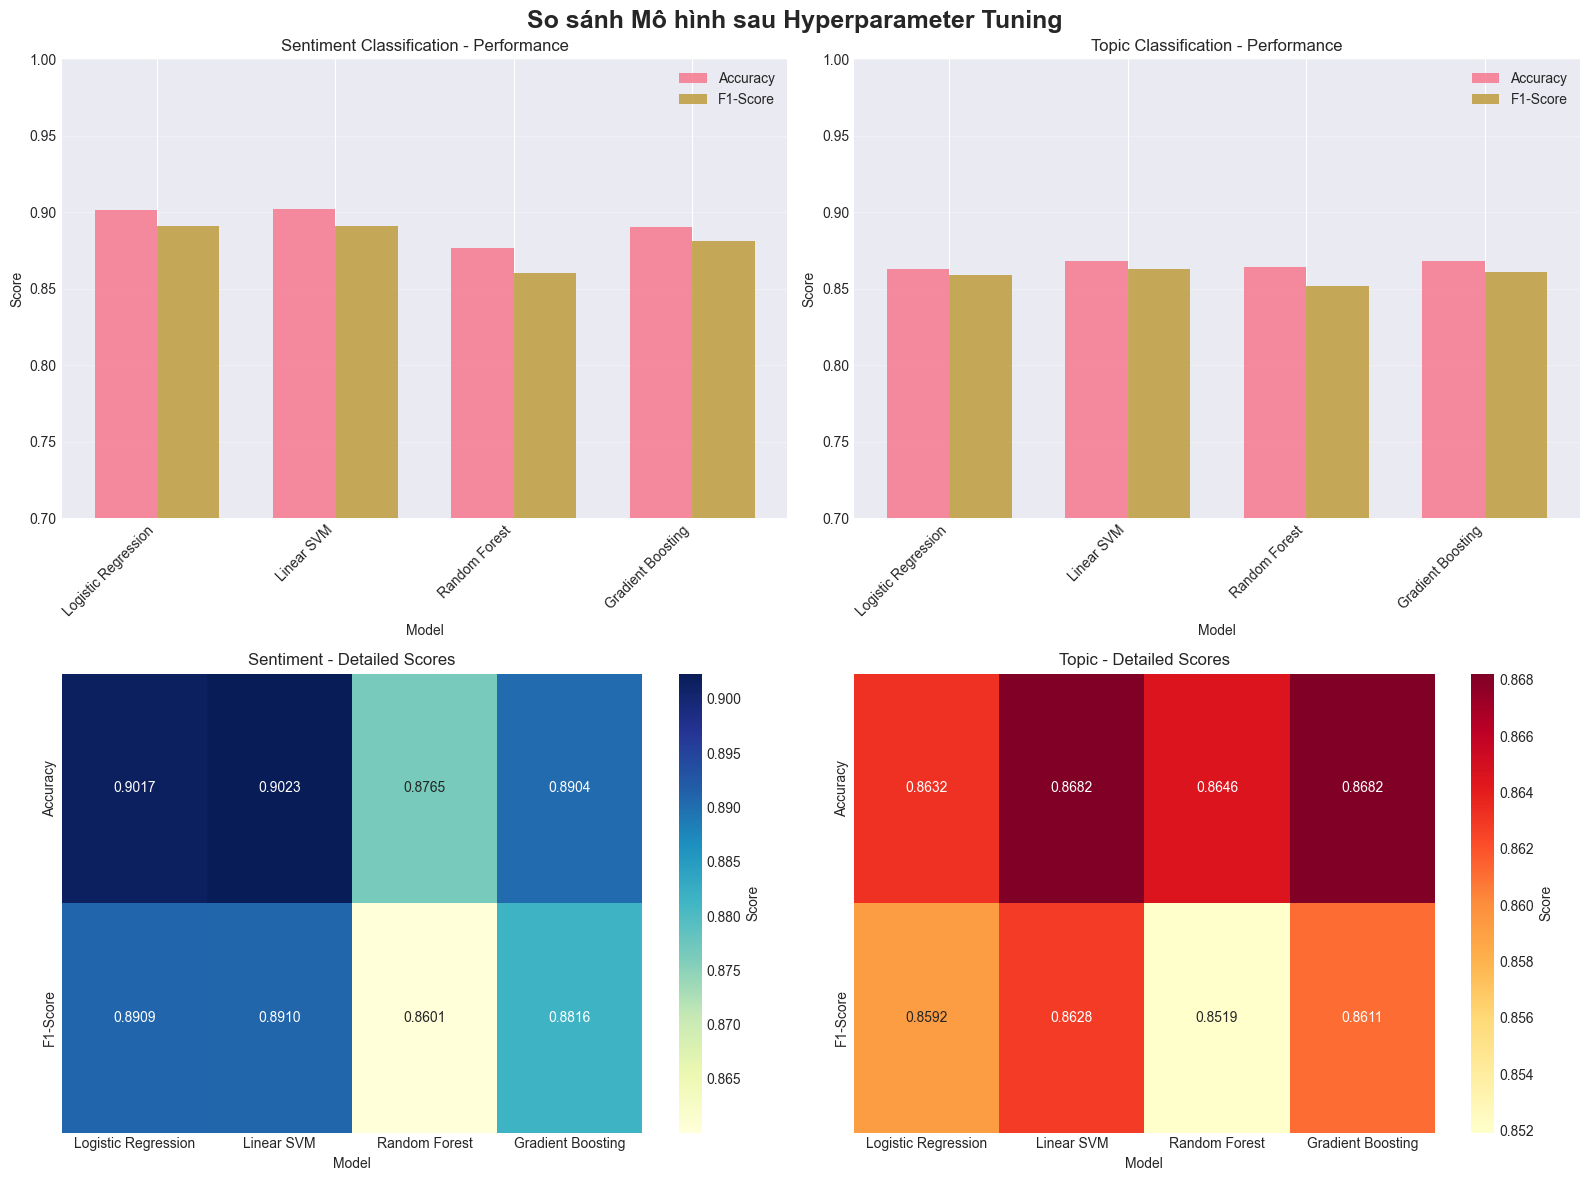


7. MÔ HÌNH TỐT NHẤT SAU TUNING

🏆 MÔ HÌNH TỐT NHẤT:
  Sentiment: Linear SVM
    - Accuracy: 0.9023
    - F1-Score: 0.8910

  Topic: Linear SVM
    - Accuracy: 0.8682
    - F1-Score: 0.8628

📋 CLASSIFICATION REPORT - SENTIMENT:
              precision    recall  f1-score   support

    negative       0.89      0.95      0.92      1369
     neutral       0.64      0.16      0.25       135
    positive       0.92      0.92      0.92      1516

    accuracy                           0.90      3020
   macro avg       0.82      0.68      0.70      3020
weighted avg       0.89      0.90      0.89      3020


📋 CLASSIFICATION REPORT - TOPIC:
                  precision    recall  f1-score   support

        lecturer       0.92      0.94      0.93      2211
training_program       0.69      0.72      0.70       551
        facility       0.93      0.89      0.91       144
          others       0.55      0.25      0.34       114

        accuracy                           0.87      3020
       

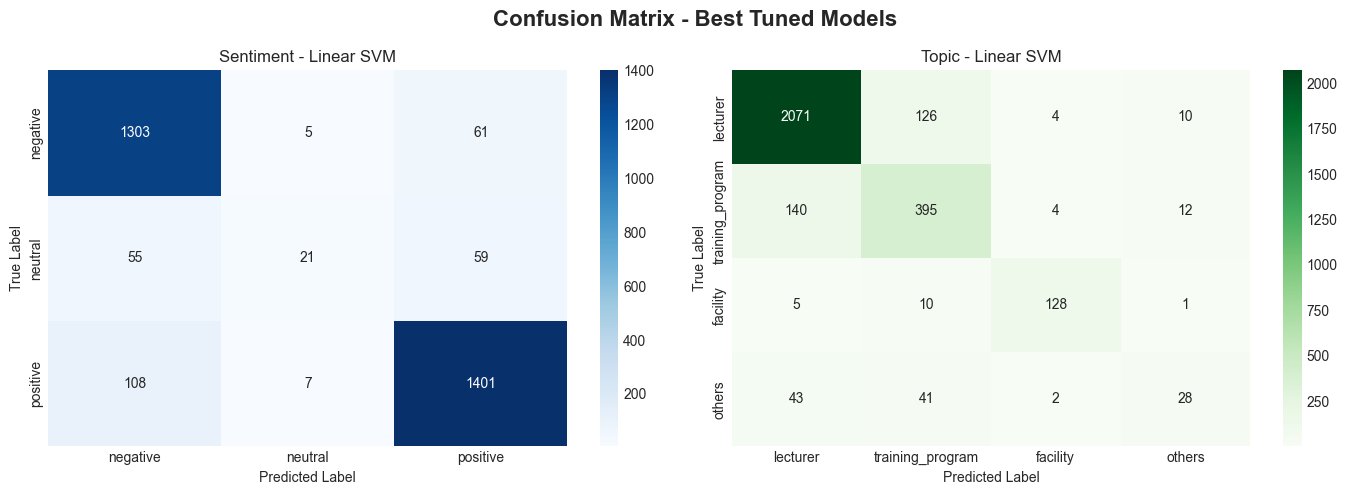


8. LƯU CÁC MÔ HÌNH ĐÃ TUNE
  ✓ Đã lưu best sentiment model: Linear SVM
  ✓ Đã lưu best topic model: Linear SVM
  ✓ Đã lưu optimized sentiment vectorizer
  ✓ Đã lưu optimized topic vectorizer
  ✓ Đã lưu thông tin tuning

✅ HOÀN THÀNH HYPERPARAMETER TUNING!

Tất cả models đã được lưu tại: tuned_models/

🎯 Kết quả cuối cùng:
  Sentiment - Linear SVM: F1=0.8910
  Topic - Linear SVM: F1=0.8628

💡 Bước tiếp theo có thể:
  - Thử Deep Learning (LSTM, PhoBERT)
  - Ensemble methods (voting, stacking)
  - Deploy model thành API


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, make_scorer
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("🔧 HYPERPARAMETER TUNING VÀ TỐI ƯU HÓA MÔ HÌNH")
print("=" * 80)

# Giả sử bạn đã có X_train, X_test, y_train, y_test từ bước trước
# X_train_tfidf_sent, X_test_tfidf_sent, y_train_sent, y_test_sent
# X_train_tfidf_topic, X_test_tfidf_topic, y_train_topic, y_test_topic

# ============================================================================
# 1. TỐI ƯU TF-IDF VECTORIZER
# ============================================================================
print("\n" + "=" * 80)
print("1. TỐI ƯU TF-IDF VECTORIZER")
print("=" * 80)

def optimize_tfidf(X_train, y_train, X_test, y_test, task_name="Task"):
    """
    Tìm tham số tốt nhất cho TF-IDF Vectorizer
    """
    print(f"\n🔍 Tối ưu TF-IDF cho {task_name}...")
    
    # Các tham số cần thử
    tfidf_params = {
        'max_features': [3000, 5000, 7000, 10000],
        'ngram_range': [(1, 1), (1, 2), (1, 3)],
        'min_df': [1, 2, 3],
        'max_df': [0.9, 0.95, 1.0],
        'sublinear_tf': [True, False]
    }
    
    best_score = 0
    best_params = {}
    best_vectorizer = None
    best_features = None
    
    # Thử từng combination (simplified search)
    print("  Đang thử các tham số...")
    test_configs = [
        {'max_features': 5000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True},
        {'max_features': 7000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True},
        {'max_features': 5000, 'ngram_range': (1, 3), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True},
        {'max_features': 10000, 'ngram_range': (1, 2), 'min_df': 1, 'max_df': 0.9, 'sublinear_tf': True},
    ]
    
    for params in test_configs:
        vectorizer = TfidfVectorizer(**params)
        X_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)
        
        # Quick test với Logistic Regression
        model = LogisticRegression(max_iter=500, random_state=42)
        model.fit(X_vec, y_train)
        score = f1_score(y_test, model.predict(X_test_vec), average='weighted')
        
        if score > best_score:
            best_score = score
            best_params = params
            best_vectorizer = vectorizer
            best_features = X_vec, X_test_vec
        
        print(f"    {params['max_features']} features, {params['ngram_range']} ngrams: F1={score:.4f}")
    
    print(f"\n  ✓ Best TF-IDF params: {best_params}")
    print(f"  ✓ Best F1-Score: {best_score:.4f}")
    
    return best_vectorizer, best_features, best_params

# Tối ưu cho Sentiment
print("\n📊 SENTIMENT CLASSIFICATION:")
tfidf_sent_opt, (X_train_opt_sent, X_test_opt_sent), tfidf_params_sent = optimize_tfidf(
    X_train_sent, y_train_sent, X_test_sent, y_test_sent, "Sentiment"
)

# Tối ưu cho Topic
print("\n📊 TOPIC CLASSIFICATION:")
tfidf_topic_opt, (X_train_opt_topic, X_test_opt_topic), tfidf_params_topic = optimize_tfidf(
    X_train_topic, y_train_topic, X_test_topic, y_test_topic, "Topic"
)

# ============================================================================
# 2. HYPERPARAMETER TUNING - LOGISTIC REGRESSION
# ============================================================================
print("\n" + "=" * 80)
print("2. HYPERPARAMETER TUNING - LOGISTIC REGRESSION")
print("=" * 80)

def tune_logistic_regression(X_train, y_train, X_test, y_test, task_name="Task"):
    """
    Tối ưu Logistic Regression với GridSearchCV
    """
    print(f"\n🔧 Tuning Logistic Regression cho {task_name}...")
    
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear', 'saga'],
        'max_iter': [500, 1000]
    }
    
    lr = LogisticRegression(random_state=42)
    
    grid_search = GridSearchCV(
        lr,
        param_grid,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    
    print(f"\n  ✓ Best params: {grid_search.best_params_}")
    print(f"  ✓ Best CV score: {grid_search.best_score_:.4f}")
    print(f"  ✓ Training time: {elapsed_time:.2f}s")
    
    # Test trên test set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    test_acc = accuracy_score(y_test, y_pred)
    
    print(f"  ✓ Test Accuracy: {test_acc:.4f}")
    print(f"  ✓ Test F1-Score: {test_f1:.4f}")
    
    return best_model, grid_search.best_params_, test_f1, test_acc

# Tune cho Sentiment
print("\n📊 SENTIMENT:")
lr_sent_tuned, lr_params_sent, lr_f1_sent, lr_acc_sent = tune_logistic_regression(
    X_train_opt_sent, y_train_sent, X_test_opt_sent, y_test_sent, "Sentiment"
)

# Tune cho Topic
print("\n📊 TOPIC:")
lr_topic_tuned, lr_params_topic, lr_f1_topic, lr_acc_topic = tune_logistic_regression(
    X_train_opt_topic, y_train_topic, X_test_opt_topic, y_test_topic, "Topic"
)

# ============================================================================
# 3. HYPERPARAMETER TUNING - LINEAR SVM
# ============================================================================
print("\n" + "=" * 80)
print("3. HYPERPARAMETER TUNING - LINEAR SVM")
print("=" * 80)

def tune_linear_svm(X_train, y_train, X_test, y_test, task_name="Task"):
    """
    Tối ưu Linear SVM với GridSearchCV
    """
    print(f"\n🔧 Tuning Linear SVM cho {task_name}...")
    
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'loss': ['hinge', 'squared_hinge'],
        'max_iter': [1000, 2000]
    }
    
    svm = LinearSVC(random_state=42)
    
    grid_search = GridSearchCV(
        svm,
        param_grid,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    
    print(f"\n  ✓ Best params: {grid_search.best_params_}")
    print(f"  ✓ Best CV score: {grid_search.best_score_:.4f}")
    print(f"  ✓ Training time: {elapsed_time:.2f}s")
    
    # Test trên test set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    test_acc = accuracy_score(y_test, y_pred)
    
    print(f"  ✓ Test Accuracy: {test_acc:.4f}")
    print(f"  ✓ Test F1-Score: {test_f1:.4f}")
    
    return best_model, grid_search.best_params_, test_f1, test_acc

# Tune cho Sentiment
print("\n📊 SENTIMENT:")
svm_sent_tuned, svm_params_sent, svm_f1_sent, svm_acc_sent = tune_linear_svm(
    X_train_opt_sent, y_train_sent, X_test_opt_sent, y_test_sent, "Sentiment"
)

# Tune cho Topic
print("\n📊 TOPIC:")
svm_topic_tuned, svm_params_topic, svm_f1_topic, svm_acc_topic = tune_linear_svm(
    X_train_opt_topic, y_train_topic, X_test_opt_topic, y_test_topic, "Topic"
)

# ============================================================================
# 4. HYPERPARAMETER TUNING - RANDOM FOREST
# ============================================================================
print("\n" + "=" * 80)
print("4. HYPERPARAMETER TUNING - RANDOM FOREST")
print("=" * 80)

def tune_random_forest(X_train, y_train, X_test, y_test, task_name="Task"):
    """
    Tối ưu Random Forest với RandomizedSearchCV (nhanh hơn GridSearch)
    """
    print(f"\n🔧 Tuning Random Forest cho {task_name}...")
    
    param_dist = {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    
    random_search = RandomizedSearchCV(
        rf,
        param_dist,
        n_iter=20,  # Số lượng combinations thử
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    start_time = time.time()
    random_search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    
    print(f"\n  ✓ Best params: {random_search.best_params_}")
    print(f"  ✓ Best CV score: {random_search.best_score_:.4f}")
    print(f"  ✓ Training time: {elapsed_time:.2f}s")
    
    # Test trên test set
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    test_acc = accuracy_score(y_test, y_pred)
    
    print(f"  ✓ Test Accuracy: {test_acc:.4f}")
    print(f"  ✓ Test F1-Score: {test_f1:.4f}")
    
    return best_model, random_search.best_params_, test_f1, test_acc

# Tune cho Sentiment
print("\n📊 SENTIMENT:")
rf_sent_tuned, rf_params_sent, rf_f1_sent, rf_acc_sent = tune_random_forest(
    X_train_opt_sent, y_train_sent, X_test_opt_sent, y_test_sent, "Sentiment"
)

# Tune cho Topic
print("\n📊 TOPIC:")
rf_topic_tuned, rf_params_topic, rf_f1_topic, rf_acc_topic = tune_random_forest(
    X_train_opt_topic, y_train_topic, X_test_opt_topic, y_test_topic, "Topic"
)

# ============================================================================
# 5. THÊM GRADIENT BOOSTING (BONUS)
# ============================================================================
print("\n" + "=" * 80)
print("5. THÊM GRADIENT BOOSTING CLASSIFIER")
print("=" * 80)

def tune_gradient_boosting(X_train, y_train, X_test, y_test, task_name="Task"):
    """
    Tối ưu Gradient Boosting
    """
    print(f"\n🔧 Tuning Gradient Boosting cho {task_name}...")
    
    param_dist = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }
    
    gb = GradientBoostingClassifier(random_state=42)
    
    random_search = RandomizedSearchCV(
        gb,
        param_dist,
        n_iter=15,
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    start_time = time.time()
    random_search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    
    print(f"\n  ✓ Best params: {random_search.best_params_}")
    print(f"  ✓ Best CV score: {random_search.best_score_:.4f}")
    print(f"  ✓ Training time: {elapsed_time:.2f}s")
    
    # Test
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    test_acc = accuracy_score(y_test, y_pred)
    
    print(f"  ✓ Test Accuracy: {test_acc:.4f}")
    print(f"  ✓ Test F1-Score: {test_f1:.4f}")
    
    return best_model, random_search.best_params_, test_f1, test_acc

# Tune cho Sentiment
print("\n📊 SENTIMENT:")
gb_sent_tuned, gb_params_sent, gb_f1_sent, gb_acc_sent = tune_gradient_boosting(
    X_train_opt_sent, y_train_sent, X_test_opt_sent, y_test_sent, "Sentiment"
)

# Tune cho Topic
print("\n📊 TOPIC:")
gb_topic_tuned, gb_params_topic, gb_f1_topic, gb_acc_topic = tune_gradient_boosting(
    X_train_opt_topic, y_train_topic, X_test_opt_topic, y_test_topic, "Topic"
)

# ============================================================================
# 6. SO SÁNH TẤT CẢ CÁC MÔ HÌNH ĐÃ TUNE
# ============================================================================
print("\n" + "=" * 80)
print("6. SO SÁNH TẤT CẢ CÁC MÔ HÌNH ĐÃ TUNE")
print("=" * 80)

# Tạo comparison DataFrame
tuned_results_sent = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [lr_acc_sent, svm_acc_sent, rf_acc_sent, gb_acc_sent],
    'F1-Score': [lr_f1_sent, svm_f1_sent, rf_f1_sent, gb_f1_sent]
})

tuned_results_topic = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [lr_acc_topic, svm_acc_topic, rf_acc_topic, gb_acc_topic],
    'F1-Score': [lr_f1_topic, svm_f1_topic, rf_f1_topic, gb_f1_topic]
})

print("\n📊 SENTIMENT CLASSIFICATION (TUNED):")
print(tuned_results_sent.sort_values('F1-Score', ascending=False).to_string(index=False))

print("\n📊 TOPIC CLASSIFICATION (TUNED):")
print(tuned_results_topic.sort_values('F1-Score', ascending=False).to_string(index=False))

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('So sánh Mô hình sau Hyperparameter Tuning', fontsize=18, fontweight='bold')

# Sentiment - Bar chart
x = np.arange(len(tuned_results_sent))
width = 0.35
axes[0, 0].bar(x - width/2, tuned_results_sent['Accuracy'], width, label='Accuracy', alpha=0.8)
axes[0, 0].bar(x + width/2, tuned_results_sent['F1-Score'], width, label='F1-Score', alpha=0.8)
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Sentiment Classification - Performance')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(tuned_results_sent['Model'], rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].set_ylim([0.7, 1.0])
axes[0, 0].grid(axis='y', alpha=0.3)

# Topic - Bar chart
x = np.arange(len(tuned_results_topic))
axes[0, 1].bar(x - width/2, tuned_results_topic['Accuracy'], width, label='Accuracy', alpha=0.8)
axes[0, 1].bar(x + width/2, tuned_results_topic['F1-Score'], width, label='F1-Score', alpha=0.8)
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Topic Classification - Performance')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(tuned_results_topic['Model'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].set_ylim([0.7, 1.0])
axes[0, 1].grid(axis='y', alpha=0.3)

# Sentiment - Heatmap
sent_data = tuned_results_sent[['Accuracy', 'F1-Score']].values.T
sns.heatmap(sent_data, annot=True, fmt='.4f', cmap='YlGnBu', 
            xticklabels=tuned_results_sent['Model'], 
            yticklabels=['Accuracy', 'F1-Score'],
            ax=axes[1, 0], cbar_kws={'label': 'Score'})
axes[1, 0].set_title('Sentiment - Detailed Scores')
axes[1, 0].set_xlabel('Model')

# Topic - Heatmap
topic_data = tuned_results_topic[['Accuracy', 'F1-Score']].values.T
sns.heatmap(topic_data, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=tuned_results_topic['Model'],
            yticklabels=['Accuracy', 'F1-Score'],
            ax=axes[1, 1], cbar_kws={'label': 'Score'})
axes[1, 1].set_title('Topic - Detailed Scores')
axes[1, 1].set_xlabel('Model')

plt.tight_layout()
plt.show()

# ============================================================================
# 7. FINAL BEST MODELS VÀ DETAILED ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("7. MÔ HÌNH TỐT NHẤT SAU TUNING")
print("=" * 80)

# Tìm best models
best_sent_idx = tuned_results_sent['F1-Score'].idxmax()
best_topic_idx = tuned_results_topic['F1-Score'].idxmax()

best_sent_name = tuned_results_sent.iloc[best_sent_idx]['Model']
best_topic_name = tuned_results_topic.iloc[best_topic_idx]['Model']

print(f"\n🏆 MÔ HÌNH TỐT NHẤT:")
print(f"  Sentiment: {best_sent_name}")
print(f"    - Accuracy: {tuned_results_sent.iloc[best_sent_idx]['Accuracy']:.4f}")
print(f"    - F1-Score: {tuned_results_sent.iloc[best_sent_idx]['F1-Score']:.4f}")

print(f"\n  Topic: {best_topic_name}")
print(f"    - Accuracy: {tuned_results_topic.iloc[best_topic_idx]['Accuracy']:.4f}")
print(f"    - F1-Score: {tuned_results_topic.iloc[best_topic_idx]['F1-Score']:.4f}")

# Map model names to objects
model_map_sent = {
    'Logistic Regression': lr_sent_tuned,
    'Linear SVM': svm_sent_tuned,
    'Random Forest': rf_sent_tuned,
    'Gradient Boosting': gb_sent_tuned
}

model_map_topic = {
    'Logistic Regression': lr_topic_tuned,
    'Linear SVM': svm_topic_tuned,
    'Random Forest': rf_topic_tuned,
    'Gradient Boosting': gb_topic_tuned
}

final_best_sent = model_map_sent[best_sent_name]
final_best_topic = model_map_topic[best_topic_name]

# Classification reports
print("\n📋 CLASSIFICATION REPORT - SENTIMENT:")
sentiment_labels = ['negative', 'neutral', 'positive']
y_pred_sent = final_best_sent.predict(X_test_opt_sent)
print(classification_report(y_test_sent, y_pred_sent, target_names=sentiment_labels))

print("\n📋 CLASSIFICATION REPORT - TOPIC:")
topic_labels = ['lecturer', 'training_program', 'facility', 'others']
y_pred_topic = final_best_topic.predict(X_test_opt_topic)
print(classification_report(y_test_topic, y_pred_topic, target_names=topic_labels))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix - Best Tuned Models', fontsize=16, fontweight='bold')

cm_sent = confusion_matrix(y_test_sent, y_pred_sent)
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues',
            xticklabels=sentiment_labels, yticklabels=sentiment_labels, ax=axes[0])
axes[0].set_title(f'Sentiment - {best_sent_name}')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_topic = confusion_matrix(y_test_topic, y_pred_topic)
sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Greens',
            xticklabels=topic_labels, yticklabels=topic_labels, ax=axes[1])
axes[1].set_title(f'Topic - {best_topic_name}')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ============================================================================
# 8. LƯU TẤT CẢ MÔ HÌNH ĐÃ TUNE
# ============================================================================
print("\n" + "=" * 80)
print("8. LƯU CÁC MÔ HÌNH ĐÃ TUNE")
print("=" * 80)

tuned_models_dir = Path("tuned_models")
tuned_models_dir.mkdir(exist_ok=True)

# Lưu best models
with open(tuned_models_dir / 'best_sentiment_model.pkl', 'wb') as f:
    pickle.dump(final_best_sent, f)
print(f"  ✓ Đã lưu best sentiment model: {best_sent_name}")

with open(tuned_models_dir / 'best_topic_model.pkl', 'wb') as f:
    pickle.dump(final_best_topic, f)
print(f"  ✓ Đã lưu best topic model: {best_topic_name}")

# Lưu optimized vectorizers
with open(tuned_models_dir / 'optimized_tfidf_sentiment.pkl', 'wb') as f:
    pickle.dump(tfidf_sent_opt, f)
print(f"  ✓ Đã lưu optimized sentiment vectorizer")

with open(tuned_models_dir / 'optimized_tfidf_topic.pkl', 'wb') as f:
    pickle.dump(tfidf_topic_opt, f)
print(f"  ✓ Đã lưu optimized topic vectorizer")

# Lưu thông tin về hyperparameters
tuning_info = {
    'sentiment': {
        'best_model': best_sent_name,
        'tfidf_params': tfidf_params_sent,
        'model_params': {
            'Logistic Regression': lr_params_sent,
            'Linear SVM': svm_params_sent,
            'Random Forest': rf_params_sent,
            'Gradient Boosting': gb_params_sent
        },
        'performance': tuned_results_sent.to_dict()
    },
    'topic': {
        'best_model': best_topic_name,
        'tfidf_params': tfidf_params_topic,
        'model_params': {
            'Logistic Regression': lr_params_topic,
            'Linear SVM': svm_params_topic,
            'Random Forest': rf_params_topic,
            'Gradient Boosting': gb_params_topic
        },
        'performance': tuned_results_topic.to_dict()
    }
}

with open(tuned_models_dir / 'tuning_info.pkl', 'wb') as f:
    pickle.dump(tuning_info, f)
print(f"  ✓ Đã lưu thông tin tuning")

print("\n" + "=" * 80)
print("✅ HOÀN THÀNH HYPERPARAMETER TUNING!")
print("=" * 80)
print(f"\nTất cả models đã được lưu tại: {tuned_models_dir}/")
print("\n🎯 Kết quả cuối cùng:")
print(f"  Sentiment - {best_sent_name}: F1={tuned_results_sent.iloc[best_sent_idx]['F1-Score']:.4f}")
print(f"  Topic - {best_topic_name}: F1={tuned_results_topic.iloc[best_topic_idx]['F1-Score']:.4f}")
print("\n💡 Bước tiếp theo có thể:")
print("  - Thử Deep Learning (LSTM, PhoBERT)")
print("  - Ensemble methods (voting, stacking)")
print("  - Deploy model thành API")